In [113]:
import pandas as pd

pd.set_option("display.max_rows", 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

In [49]:
data = pd.read_csv("cafc-open-gouv-database-2021-01-01-to-2025-09-30-extracted-2025-10-01.csv")

In [50]:
data.columns

Index(['Numéro d'identification / Number ID', 'Date Received / Date reçue',
       'Complaint Received Type', 'Country', 'Province/State',
       'Fraud and Cybercrime Thematic Categories', 'Solicitation Method',
       'Gender', 'Language of Correspondence',
       'Victim Age Range / Tranche d'âge des victimes', 'Complaint Type',
       'Number of Victims / Nombre de victimes',
       'Dollar Loss /pertes financières'],
      dtype='object')

In [51]:
data.head()

,Numéro d'identification / Number ID,Date Received / Date reçue,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range / Tranche d'âge des victimes,Complaint Type,Number of Victims / Nombre de victimes,Dollar Loss /pertes financières
0,350308,9/29/2025,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,'30 - 39,Victim,1,$0.00
1,350309,9/29/2025,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,'50 - 59,Victim,1,$0.00
2,350310,9/29/2025,Phone,Canada,Quebec,Extortion,Direct call,Female,French,'20 - 29,Attempt,0,$0.00
3,350311,9/29/2025,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,'40 - 49,Victim,1,$0.00
4,350312,9/29/2025,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,'60 - 69,Victim,1,$0.00


**Data Cleaning**

In [52]:
# Checking for null values
data.isnull().sum()

Numéro d'identification / Number ID              0
Date Received / Date reçue                       0
Complaint Received Type                          0
Country                                          0
Province/State                                   0
Fraud and Cybercrime Thematic Categories         0
Solicitation Method                              0
Gender                                           0
Language of Correspondence                       0
Victim Age Range / Tranche d'âge des victimes    0
Complaint Type                                   0
Number of Victims / Nombre de victimes           0
Dollar Loss /pertes financières                  0
dtype: int64

In [53]:
# Changing column names
data.columns = ['Number ID', 'Date Received',
       'Complaint Received Type', 'Country', 'Province',
       'Fraud and Cybercrime Thematic Categories', 'Solicitation Method',
       'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type',
       'Number of Victims',
       'Dollar Loss']

In [54]:
data.columns

Index(['Number ID', 'Date Received', 'Complaint Received Type', 'Country',
       'Province', 'Fraud and Cybercrime Thematic Categories',
       'Solicitation Method', 'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type', 'Number of Victims',
       'Dollar Loss'],
      dtype='object')

In [55]:
# Checking datatypes
data.dtypes

Number ID                                    int64
Date Received                               object
Complaint Received Type                     object
Country                                     object
Province                                    object
Fraud and Cybercrime Thematic Categories    object
Solicitation Method                         object
Gender                                      object
Language of Correspondence                  object
Victim Age Range                            object
Complaint Type                              object
Number of Victims                            int64
Dollar Loss                                 object
dtype: object

In [56]:
data["Date Received"] = pd.to_datetime(data["Date Received"])

In [57]:
data["Victim Age Range"] = data["Victim Age Range"].str.strip("'")

In [58]:
data["Dollar Loss"] = data["Dollar Loss"].str.strip("$")

In [59]:
data["Dollar Loss"] = data["Dollar Loss"].str.replace(",", "").astype(float)

In [60]:
data.dtypes

Number ID                                            int64
Date Received                               datetime64[ns]
Complaint Received Type                             object
Country                                             object
Province                                            object
Fraud and Cybercrime Thematic Categories            object
Solicitation Method                                 object
Gender                                              object
Language of Correspondence                          object
Victim Age Range                                    object
Complaint Type                                      object
Number of Victims                                    int64
Dollar Loss                                        float64
dtype: object

In [61]:
# Checking for duplicates
data.duplicated().sum()

0

In [62]:
set(data["Country"].unique())

{'Afghanistan',
 'Algeria',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belgium',
 'Benin',
 'Bermuda',
 'Bolivia, Plurinational State of',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Congo',
 'Congo, The Democratic Republic of the',
 'Costa Rica',
 'Croatia',
 'Curaçao',
 'Cyprus',
 'Czech Republic',
 "Côte d'Ivoire",
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'France, Metropolitan',
 'Gabon',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Guadeloupe',
 'Guam',
 'Guatemala',
 'Guernsey',
 'Guinea',
 'Guyana',
 'Haiti',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iran, Islamic Republic of',
 'Iraq',
 'Ireland'

In [63]:
# Normalize country names
data["Country"].replace({
    "Bolivia, Plurinational State of" : "Bolivia",
    "Congo, The Democratic Republic of the" : "Congo",
    "France, Metropolitan" : "France",
    "Iran, Islamic Republic of" : "Iran",
    "Korea, Republic of" : "South Korea",
    "Macedonia, The Former Yugoslav Republic of" : "Macedonia",
    "Palestinian Territory, Occupied" : "Palestinian",
    "Taiwan, Province of China" : "Taiwan",
    "Tanzania, United Republic of" : "Tanzania",
    "United States Minor Outlying Islands" : "Others",
    "Not Specified" : "Others",
    "Unknown" : "Others",
    "Venezuela, Bolivarian Republic of" : "Venezuela",
    "Viet Nam" : "Vietnam",
    "Virgin Islands, British" : "British Virgin Islands"
}, inplace = True)

In [64]:
data["Province"].replace("Not Specified", "Others", inplace = True)

**EDA**

In [65]:
data.describe()

,Number ID,Date Received,Number of Victims,Dollar Loss
count,350361.000000,350361,350361.000000,3.503610e+05
mean,175181.000000,2022-12-05 08:48:59.751856384,0.649076,7.670432e+03
min,1.000000,2021-01-02 00:00:00,0.000000,0.000000e+00
25%,87591.000000,2021-10-18 00:00:00,0.000000,0.000000e+00
50%,175181.000000,2022-09-16 00:00:00,1.000000,0.000000e+00
75%,262771.000000,2023-12-12 00:00:00,1.000000,0.000000e+00
max,350361.000000,2025-09-29 00:00:00,1.000000,2.361500e+07
std,101140.653169,NaN,0.477260,1.029056e+05


In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 13 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Number ID                                 350361 non-null  int64         
 1   Date Received                             350361 non-null  datetime64[ns]
 2   Complaint Received Type                   350361 non-null  object        
 3   Country                                   350361 non-null  object        
 4   Province                                  350361 non-null  object        
 5   Fraud and Cybercrime Thematic Categories  350361 non-null  object        
 6   Solicitation Method                       350361 non-null  object        
 7   Gender                                    350361 non-null  object        
 8   Language of Correspondence                350361 non-null  object        
 9   Victim Age Rang

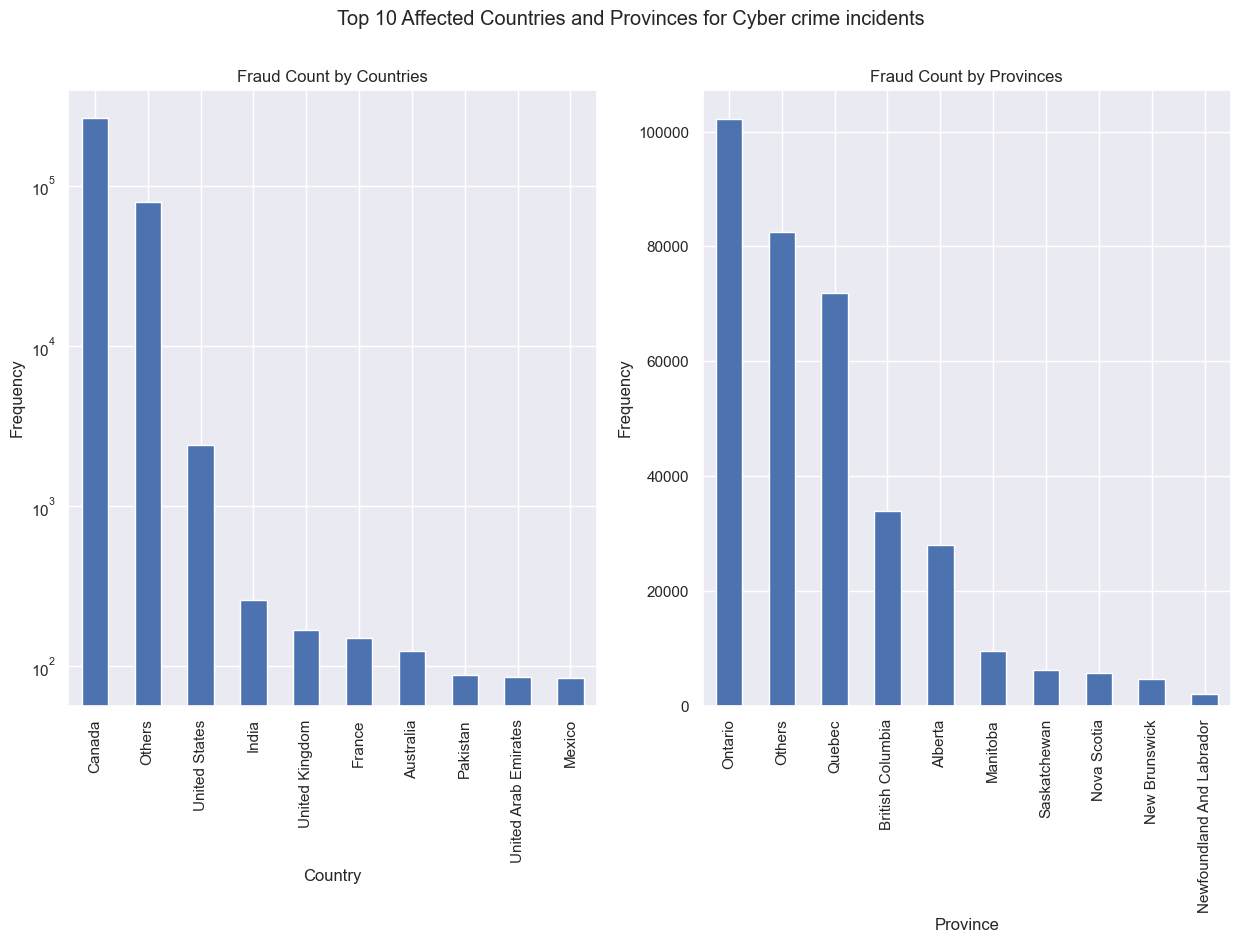

In [67]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = [15,8])
fig.suptitle("Top 10 Affected Countries and Provinces for Cyber crime incidents")

data["Country"].value_counts().head(10).plot(kind = "bar", ax =  ax1)
ax1.set_title("Fraud Count by Countries")
ax1.set_ylabel("Frequency")
ax1.set_yscale("log")

data["Province"].value_counts().head(10).plot(kind = "bar", ax =  ax2)
ax2.set_title("Fraud Count by Provinces")
ax2.set_ylabel("Frequency")

plt.show()

In [68]:
data.head()

,Number ID,Date Received,Complaint Received Type,Country,Province,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Complaint Type,Number of Victims,Dollar Loss
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,Victim,1,0.0
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,50 - 59,Victim,1,0.0
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,Attempt,0,0.0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,40 - 49,Victim,1,0.0
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,60 - 69,Victim,1,0.0


In [69]:
data["Fraud and Cybercrime Thematic Categories"].unique()

array(['Personal Info', 'Identity Fraud', 'Extortion', 'Investments',
       'Unknown', 'Service', 'Other', 'Spear Phishing', 'Romance',
       'Phishing', 'Job', 'Bank Investigator',
       'Emergency (Jail, Accident, Hospital, Help)', 'Merchandise',
       'Prize', 'Loan', 'Vendor Fraud', 'Timeshare', 'Recovery Pitch',
       'False Billing', 'Psychics', 'Collection Agency', 'GRANT',
       'Foreign Money Offer', 'Charity / Donation',
       'Counterfeit Merchandise', 'Incomplete', 'Vacation', 'Credit Card',
       'Telecom Fraud', 'Pyramid', 'Survey', 'Directory', 'Spoofing',
       'Health', 'Unauthorized Charge', 'Office Supplies',
       'Modem-Hijacking', 'Fraudulent Cheque'], dtype=object)

In [70]:
data["Date Received"].dt.to_period("y").value_counts().sort_index()

Date Received
2021    107796
2022     93091
2023     64016
2024     51728
2025     33730
Freq: A-DEC, Name: count, dtype: int64

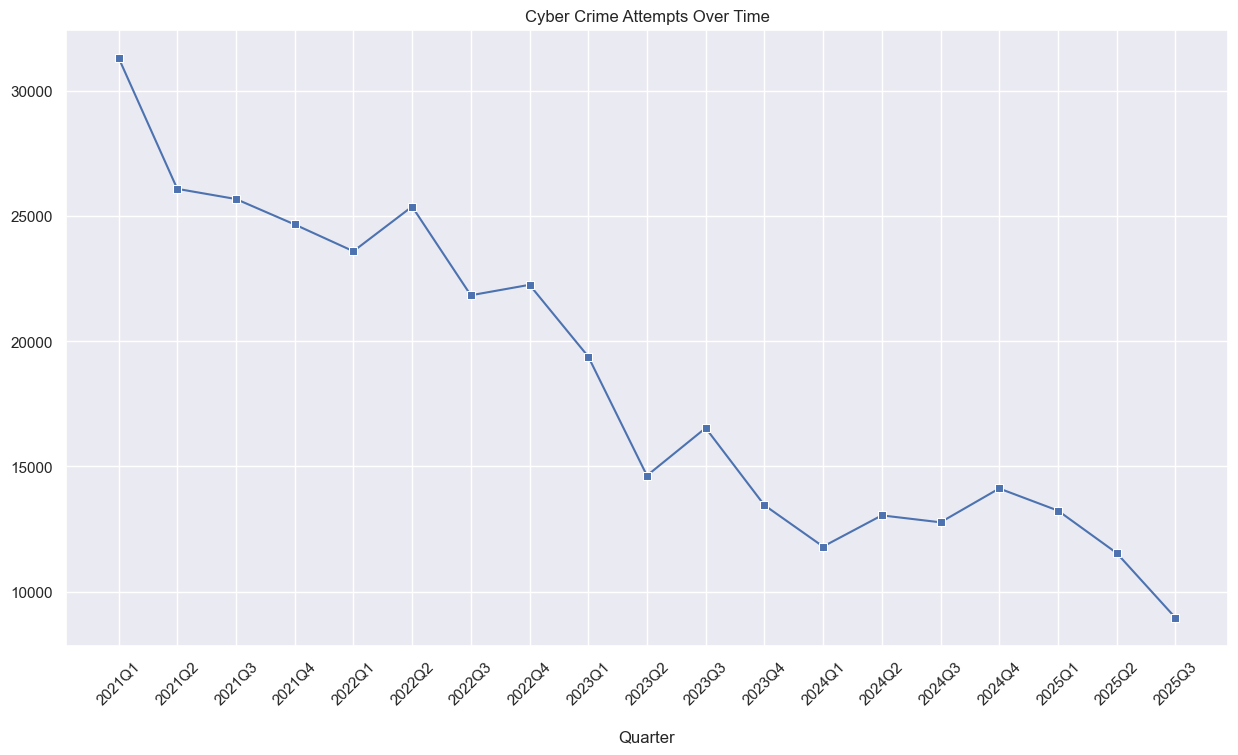

In [71]:
time_df = data["Date Received"].dt.to_period("q").value_counts().sort_index()
plt.figure(figsize = [15,8])
sns.lineplot(x = time_df.index.astype(str), y = time_df.values, marker = "s")
plt.xticks(rotation = 45)
plt.title("Cyber Crime Attempts Over Time")
plt.xlabel("\nQuarter")
plt.show()

In [72]:
data["Fraud and Cybercrime Thematic Categories"].value_counts().nlargest(10)

Fraud and Cybercrime Thematic Categories
Identity Fraud             80073
Extortion                  32779
Phishing                   30138
Personal Info              28626
Service                    26962
Investments                20394
Merchandise                18420
Bank Investigator          15134
Job                        14195
Counterfeit Merchandise    13497
Name: count, dtype: int64

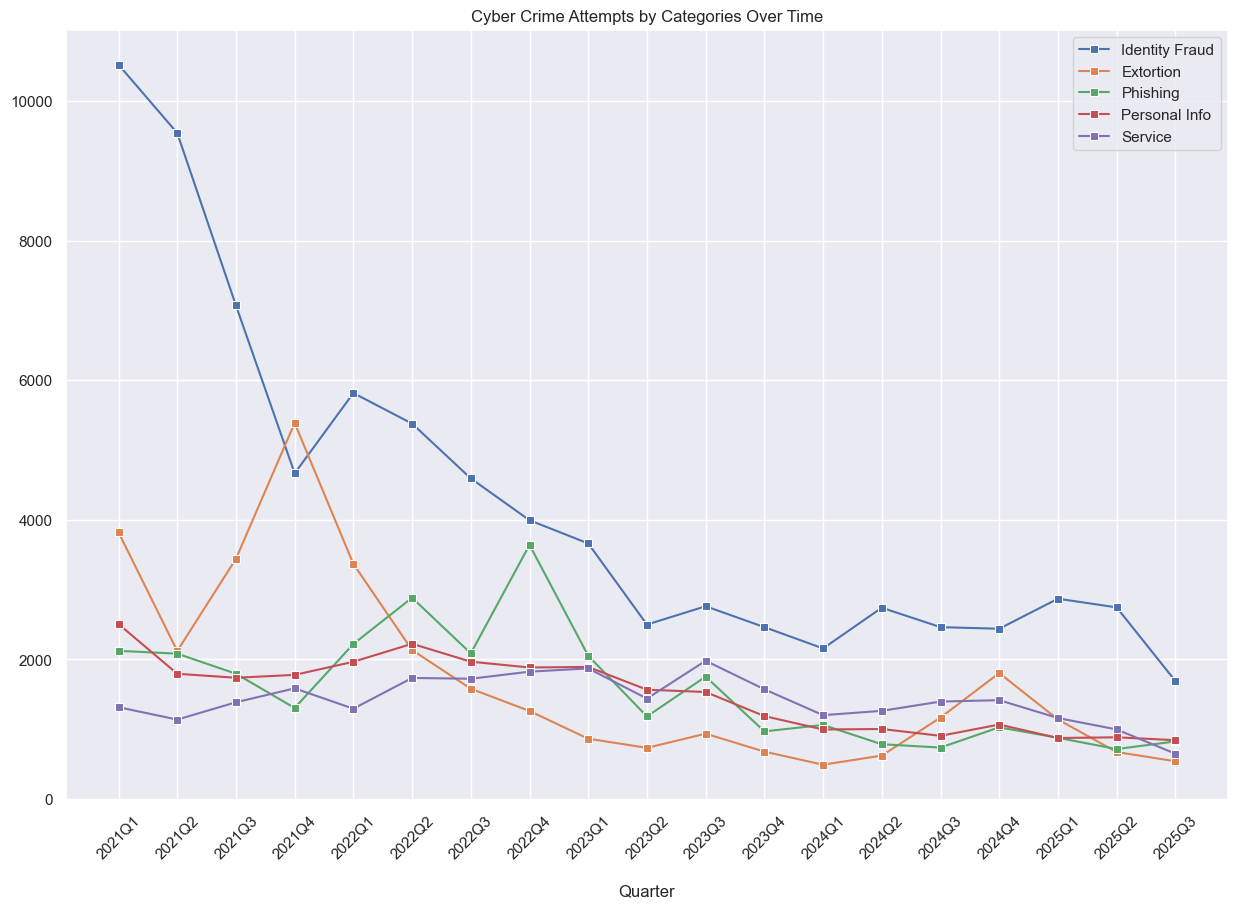

In [73]:
plt.figure(figsize = [15,10])
for i in data["Fraud and Cybercrime Thematic Categories"].value_counts().nlargest(5).index:
    req_df = data[data["Fraud and Cybercrime Thematic Categories"] == i]["Date Received"].dt.to_period("q").value_counts().sort_index()
    sns.lineplot(x = req_df.index.astype(str), y = req_df.values, marker = "s", label = i)
plt.xticks(rotation = 45)
plt.title("Cyber Crime Attempts by Categories Over Time")
plt.xlabel("\nQuarter")
plt.show()

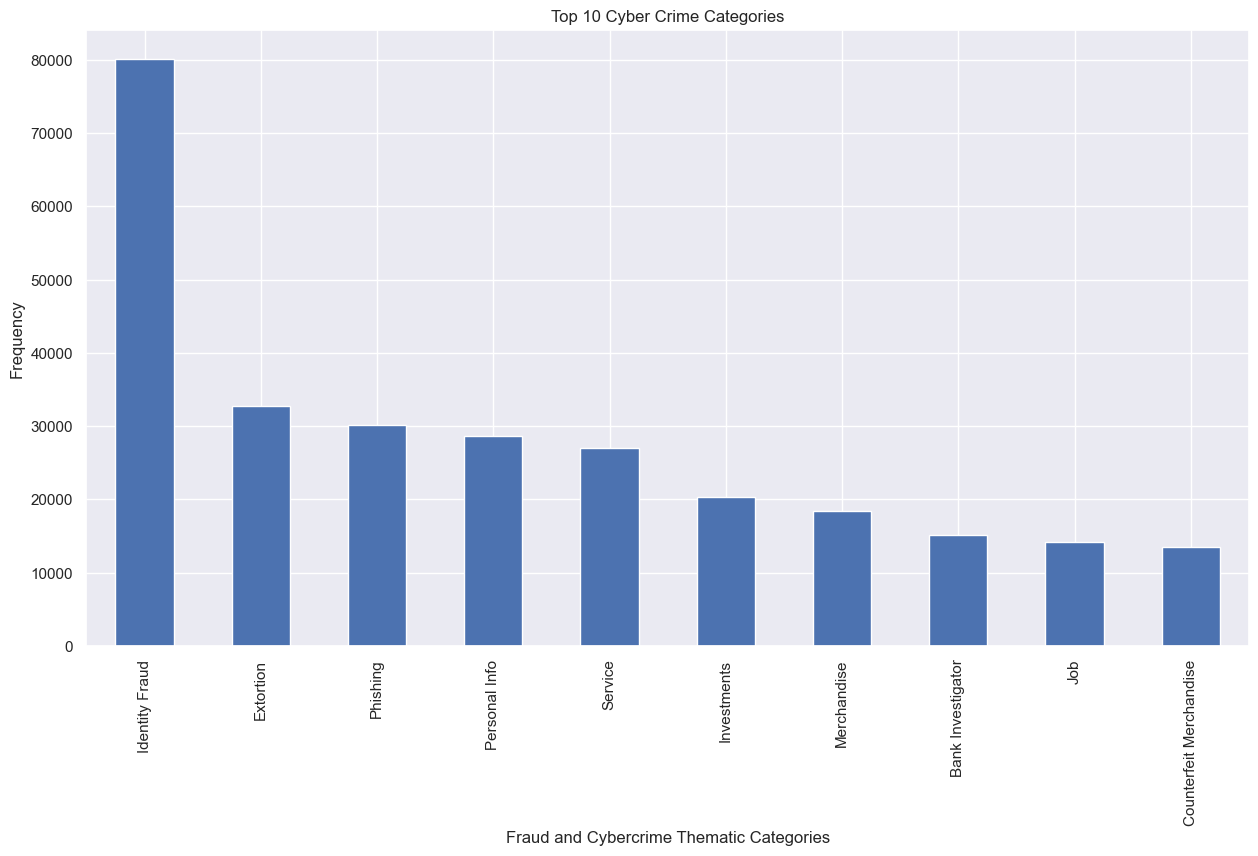

In [74]:
plt.figure(figsize = [15,8])
data["Fraud and Cybercrime Thematic Categories"].value_counts().nlargest(10).plot(kind = "bar")
plt.title("Top 10 Cyber Crime Categories")
plt.ylabel("Frequency")
plt.show()

In [75]:
data.head()

,Number ID,Date Received,Complaint Received Type,Country,Province,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Complaint Type,Number of Victims,Dollar Loss
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,Victim,1,0.0
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,50 - 59,Victim,1,0.0
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,Attempt,0,0.0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,40 - 49,Victim,1,0.0
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,60 - 69,Victim,1,0.0


In [100]:
data[data["Dollar Loss"] != 0].groupby("Fraud and Cybercrime Thematic Categories")["Dollar Loss"].mean().sort_values(ascending = False).head(10)

Fraud and Cybercrime Thematic Categories
Spear Phishing         102911.129825
Foreign Money Offer     89201.506154
Investments             80675.831337
Other                   70880.640234
Unknown                 69249.197410
Romance                 62675.502203
Timeshare               62018.192746
Recovery Pitch          43552.475331
Extortion               27930.029346
Prize                   22546.411046
Name: Dollar Loss, dtype: float64

In [102]:
fraud_type_names = data[data["Dollar Loss"] != 0].groupby("Fraud and Cybercrime Thematic Categories")["Dollar Loss"].mean().sort_values(ascending = False).head(10).index
fraud_type_names

Index(['Spear Phishing', 'Foreign Money Offer', 'Investments', 'Other',
       'Unknown', 'Romance', 'Timeshare', 'Recovery Pitch', 'Extortion',
       'Prize'],
      dtype='object', name='Fraud and Cybercrime Thematic Categories')

In [156]:
data["Quarter Date Received"] = data["Date Received"].dt.to_period("q").astype("str")

In [159]:
sorted(data["Quarter Date Received"].unique())

['2021Q1',
 '2021Q2',
 '2021Q3',
 '2021Q4',
 '2022Q1',
 '2022Q2',
 '2022Q3',
 '2022Q4',
 '2023Q1',
 '2023Q2',
 '2023Q3',
 '2023Q4',
 '2024Q1',
 '2024Q2',
 '2024Q3',
 '2024Q4',
 '2025Q1',
 '2025Q2',
 '2025Q3']

In [115]:
grouped_df = data[(data["Dollar Loss"] != 0)].groupby(["Fraud and Cybercrime Thematic Categories", "Quarter Date Received"])["Dollar Loss"].mean().to_frame().reset_index()
grouped_df

,Fraud and Cybercrime Thematic Categories,Quarter Date Received,Dollar Loss
0,Bank Investigator,2021Q1,11219.759397
1,Bank Investigator,2021Q2,10173.954488
2,Bank Investigator,2021Q3,8915.083121
3,Bank Investigator,2021Q4,8969.575385
4,Bank Investigator,2022Q1,9647.230667
...,...,...,...
513,Vendor Fraud,2024Q3,8975.368462
514,Vendor Fraud,2024Q4,33797.520493
515,Vendor Fraud,2025Q1,5738.631032
516,Vendor Fraud,2025Q2,9504.176753


In [160]:
dollar_loss_df = {
    'period' : sorted(data["Quarter Date Received"].unique()),
    'Spear Phishing' : grouped_df[grouped_df["Fraud and Cybercrime Thematic Categories"] == "Spear Phishing"]["Dollar Loss"].values,
    'Foreign Money Offer' : grouped_df[grouped_df["Fraud and Cybercrime Thematic Categories"] == "Foreign Money Offer"]["Dollar Loss"].values,
    'Investments': grouped_df[grouped_df["Fraud and Cybercrime Thematic Categories"] == "Investments"]["Dollar Loss"].values,
    'Romance' : grouped_df[grouped_df["Fraud and Cybercrime Thematic Categories"] == "Romance"]["Dollar Loss"].values,
    'Timeshare' : grouped_df[grouped_df["Fraud and Cybercrime Thematic Categories"] == "Timeshare"]["Dollar Loss"].values
}

dollar_loss_df = pd.DataFrame(dollar_loss_df)
dollar_loss_df

,period,Spear Phishing,Foreign Money Offer,Investments,Romance,Timeshare
0,2021Q1,72265.486222,90511.901429,53592.705666,40416.972567,30223.365556
1,2021Q2,73535.287970,139099.106000,52873.381924,58036.624073,82922.714444
2,2021Q3,26854.754590,22210.555000,56690.722960,57883.736286,92335.722727
3,2021Q4,146600.371342,50337.272857,61494.556744,55563.097817,172430.161667
4,2022Q1,140520.159924,79698.960000,59986.528588,71054.706014,50407.855000
5,2022Q2,60815.571769,92953.588571,58801.990739,60586.127004,89086.467273
6,2022Q3,117773.869091,160172.341429,69682.463062,57690.107150,56750.270000
7,2022Q4,63363.822737,86966.449000,126236.060767,68000.314064,30614.865000
8,2023Q1,83996.751103,84994.513571,82421.200482,72956.922885,42510.879000
9,2023Q2,153954.002254,41809.600000,102329.221596,66922.990773,51492.670000


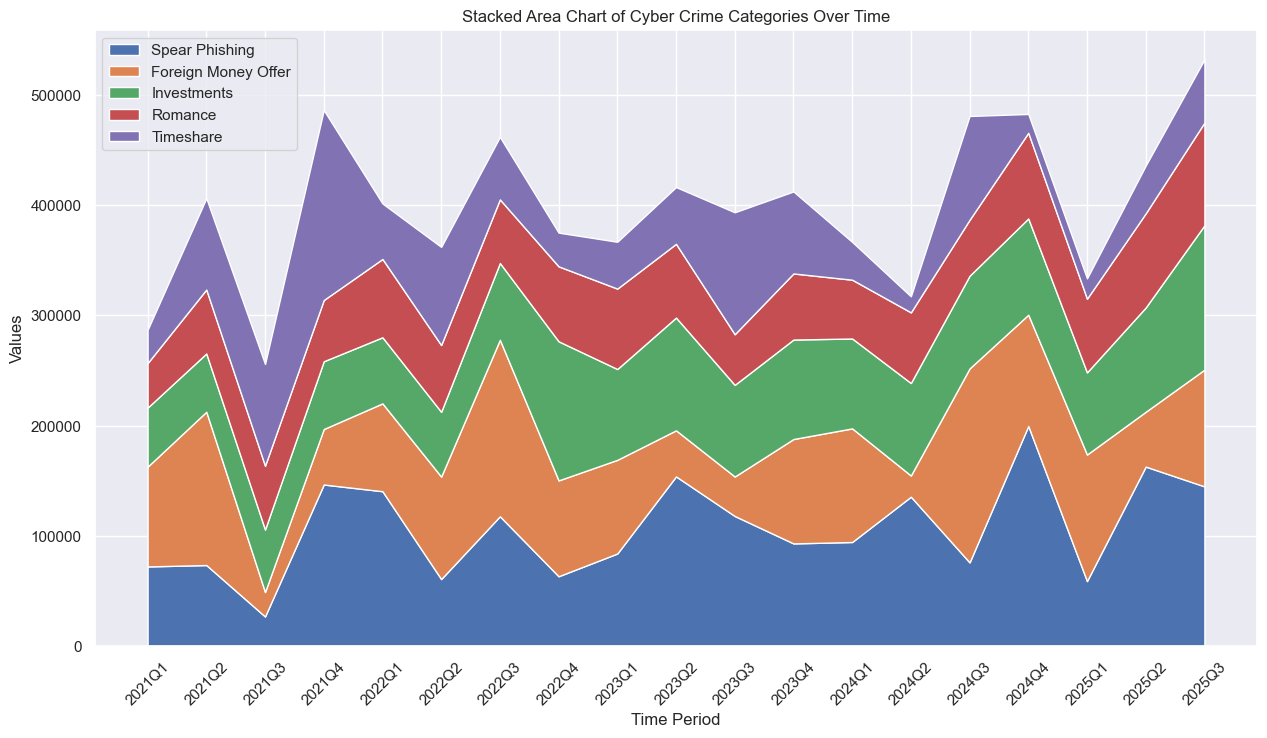

In [161]:
plt.figure(figsize = [15, 8])
plt.stackplot(
    dollar_loss_df["period"],
    dollar_loss_df["Spear Phishing"],
    dollar_loss_df["Foreign Money Offer"],
    dollar_loss_df["Investments"],
    dollar_loss_df["Romance"],
    dollar_loss_df["Timeshare"],
    labels = dollar_loss_df.columns[1:]
)

plt.legend(loc='upper left')
plt.xlabel('Time Period')
plt.xticks(rotation = 45)
plt.ylabel('Values')
plt.title('Stacked Area Chart of Cyber Crime Categories Over Time')
plt.show()

In [162]:
data.columns

Index(['Number ID', 'Date Received', 'Complaint Received Type', 'Country',
       'Province', 'Fraud and Cybercrime Thematic Categories',
       'Solicitation Method', 'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type', 'Number of Victims',
       'Dollar Loss', 'Quarter Date Received'],
      dtype='object')

In [174]:
data["Victim Age Range"].unique()

array(['30 - 39', '50 - 59', '20 - 29', '40 - 49', '60 - 69', '70 - 79',
       'Not Available / non disponible', '10 - 19', '80 - 89', '90 - 99',
       'Deceased / Décédé', '1 - 9', '100 +', 'Business / Entreprise'],
      dtype=object)

(array([    0., 10000., 20000., 30000., 40000., 50000.]),
 [Text(0.0, 0, '0'),
  Text(10000.0, 0, '10000'),
  Text(20000.0, 0, '20000'),
  Text(30000.0, 0, '30000'),
  Text(40000.0, 0, '40000'),
  Text(50000.0, 0, '50000')])

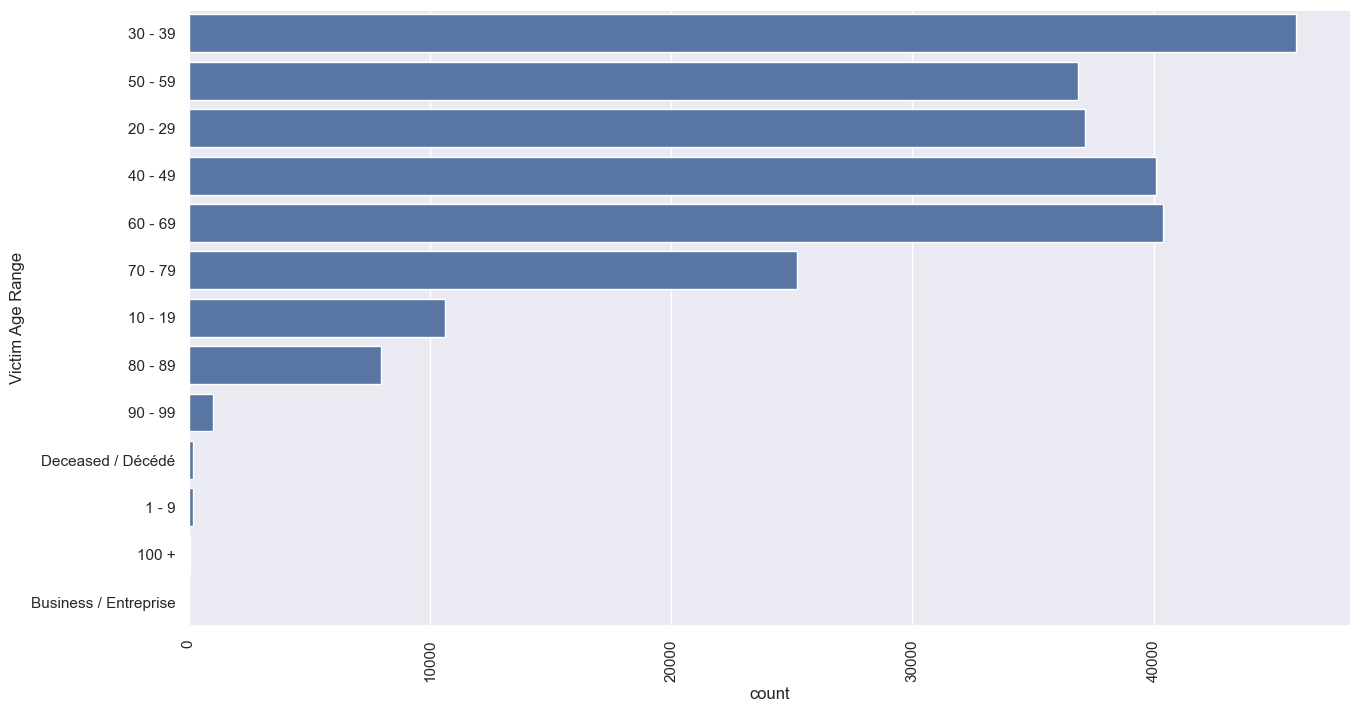

In [176]:
plt.figure(figsize = [15, 8])
sns.countplot(data = data[data["Victim Age Range"] != "Not Available / non disponible"], y = "Victim Age Range")
plt.xticks(rotation = 90)

(array([    0.,  5000., 10000., 15000., 20000., 25000.]),
 [Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000')])

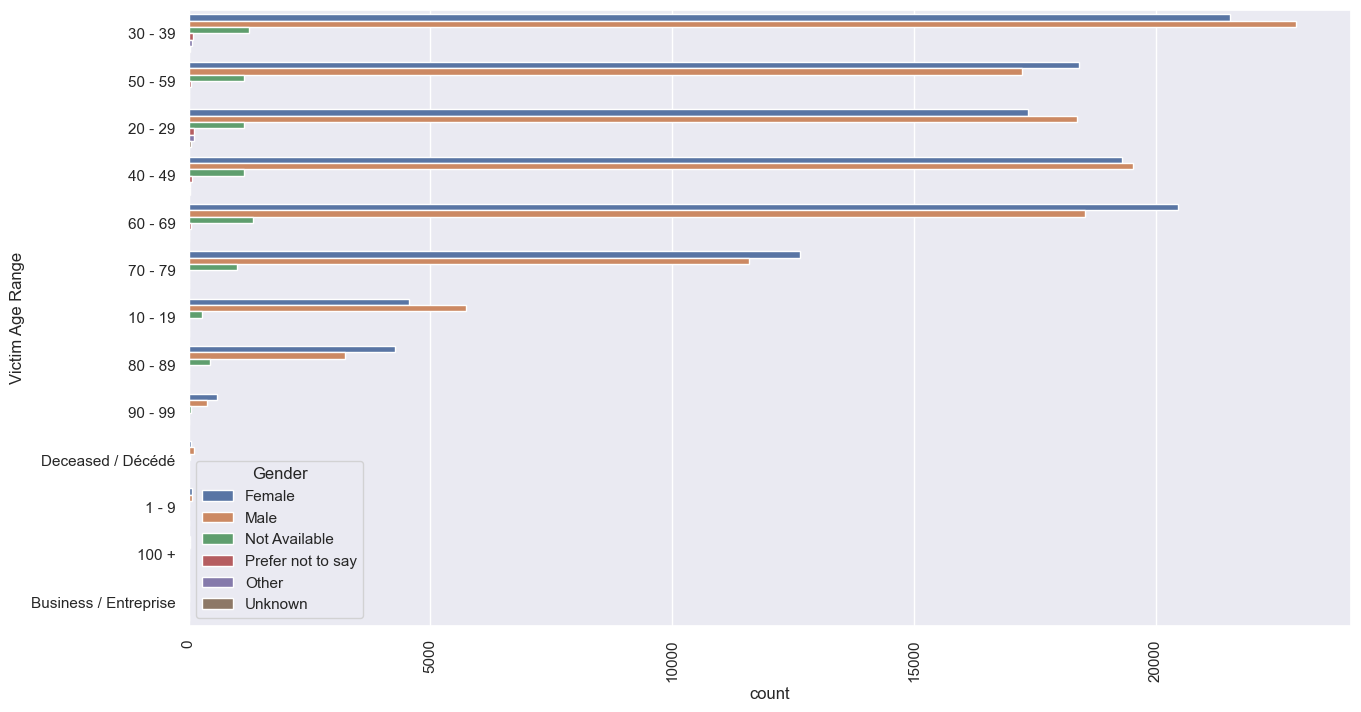

In [177]:
plt.figure(figsize = [15, 8])
sns.countplot(data = data[data["Victim Age Range"] != "Not Available / non disponible"], y = "Victim Age Range", hue = "Gender")
plt.xticks(rotation = 90)

In [179]:
data["Gender"].unique()

array(['Female', 'Male', 'Not Available', 'Prefer not to say', 'Other',
       'Unknown'], dtype=object)

In [165]:
data["Victim Age Range"].unique()

array(['30 - 39', '50 - 59', '20 - 29', '40 - 49', '60 - 69', '70 - 79',
       'Not Available / non disponible', '10 - 19', '80 - 89', '90 - 99',
       'Deceased / Décédé', '1 - 9', '100 +', 'Business / Entreprise'],
      dtype=object)

In [169]:
data[data["Victim Age Range"] == "Business / Entreprise"]

,Number ID,Date Received,Complaint Received Type,Country,Province,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Complaint Type,Number of Victims,Dollar Loss,Quarter Date Received
16277,334101,2025-05-02,Phone,Canada,Nova Scotia,Spear Phishing,Not Available,Not Available,Not Available,Business / Entreprise,Victim,1,400.00,2025Q2
16857,333433,2025-04-28,Phone,Canada,British Columbia,Spear Phishing,Not Available,Not Available,Not Available,Business / Entreprise,Victim,1,425000.00,2025Q2
19796,330503,2025-04-04,Phone,Canada,Ontario,Identity Fraud,Not Available,Not Available,Not Available,Business / Entreprise,Victim,1,0.00,2025Q2
27448,323066,2025-02-14,CAFC Website,Others,Others,Spear Phishing,Email,Not Available,English,Business / Entreprise,Victim,1,1600.00,2025Q1
52878,297387,2024-08-28,Phone,Spain,Others,Service,Internet-social network,Female,English,Business / Entreprise,Victim,1,199.66,2024Q3
60084,290354,2024-07-04,Phone,Canada,Quebec,Spear Phishing,Email,Unknown,Not Available,Business / Entreprise,Attempt,0,0.00,2024Q3
70341,280015,2024-04-20,CAFC Website,Others,Others,Spear Phishing,Email,Not Available,English,Business / Entreprise,Attempt,0,0.00,2024Q2
72344,278124,2024-04-05,Phone,Canada,Quebec,Service,Direct call,Unknown,French,Business / Entreprise,Attempt,0,0.00,2024Q2
73128,276951,2024-04-02,Email,Canada,British Columbia,Service,Other/unknown,Unknown,Not Available,Business / Entreprise,Attempt,0,0.00,2024Q2
75093,275344,2024-03-19,Phone,Canada,Quebec,Vendor Fraud,Direct call,Unknown,Not Available,Business / Entreprise,Victim,1,5058.90,2024Q1


In [168]:
data.shape

(350361, 14)